In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mean_df = pd.read_csv("results/curve_meanALL.csv")
chi_df = pd.read_csv("results/curve_chiALL.csv")
summary_df = pd.read_csv("results/summaryALL.csv")

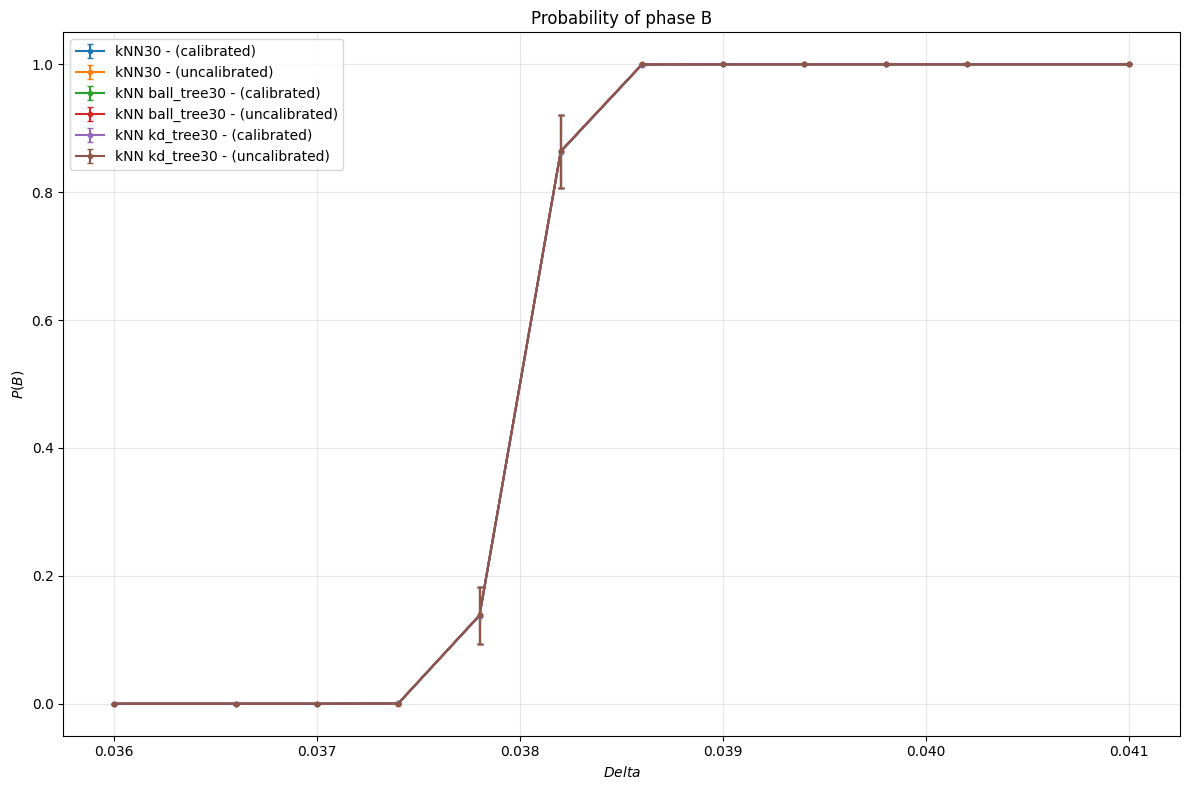

In [4]:
plt.figure(figsize=(12, 8))

for (feature_set, model, calibration), group in mean_df.groupby(
    ["feature_set", "model", "calibration"]
):
    if not model.startswith("kNN"):
        continue
    if not feature_set == 30:
        continue
    # for 
    group = group.sort_values("Delta")

    plt.errorbar(
    group["Delta"],
    group["mean"],
    yerr=group["mean_err"],
    fmt="-o",
    markersize=3,
    capsize=2,
    linewidth=1.5,
    label=f"{model}{feature_set} - ({calibration})"
        )

plt.xlabel(r"$Delta$")
plt.ylabel(r"$P(B)$")
plt.title("Probability of phase B")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# plt.savefig(
#     "results/figures/probability_all_models.png",
#     dpi=300
# )

plt.show()

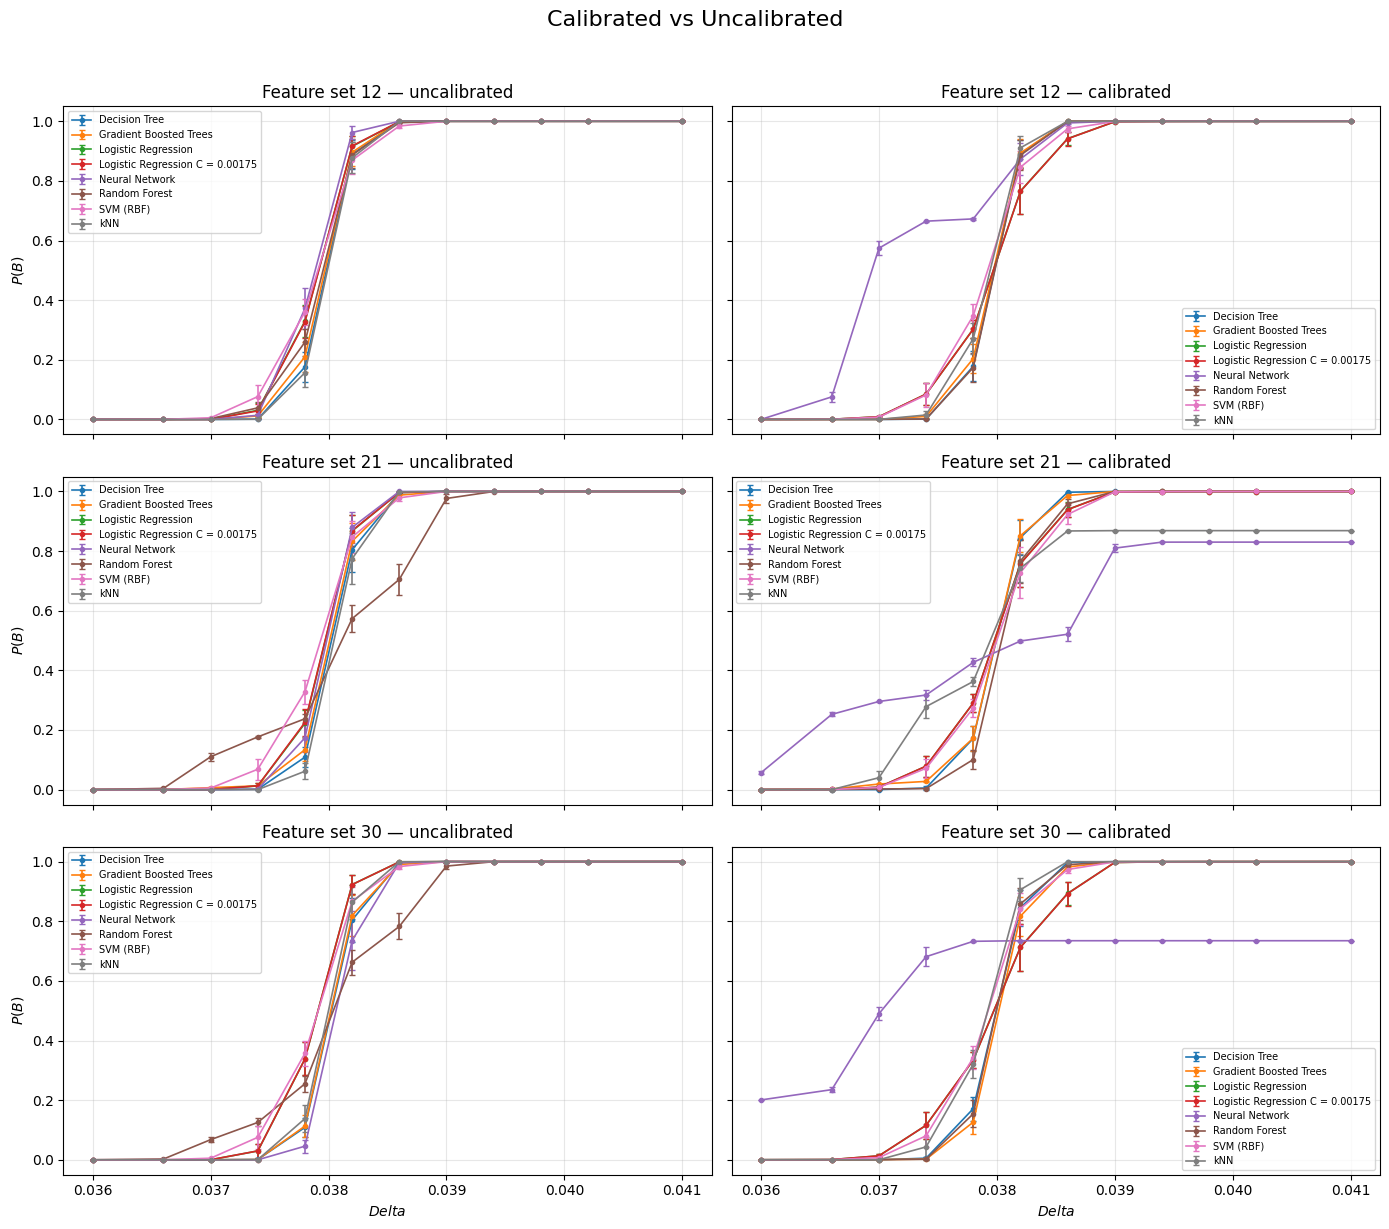

In [4]:
feature_sets = sorted(mean_df["feature_set"].unique())
calibrations = ["uncalibrated", "calibrated"]

fig, axes = plt.subplots(
    len(feature_sets),
    len(calibrations),
    figsize=(14, 4 * len(feature_sets)),
    sharex=True,
    sharey=True
)

# przypadek gdy jest tylko jeden feature_set
if len(feature_sets) == 1:
    axes = np.array([axes])

for i, fs in enumerate(feature_sets):

    for j, calib in enumerate(calibrations):

        ax = axes[i, j]

        df_plot = mean_df[
            (mean_df["feature_set"] == fs)
            &
            (mean_df["calibration"] == calib)
        ]

        for model, group in df_plot.groupby("model"):

            group = group.sort_values("Delta")

            ax.errorbar(
                group["Delta"],
                group["mean"],
                yerr=group["mean_err"],
                fmt="-o",
                markersize=3,
                capsize=2,
                linewidth=1.2,
                label=model
            )

        ax.set_title(
            f"Feature set {fs} — {calib}"
        )

        ax.grid(alpha=0.3)

        if j == 0:
            ax.set_ylabel(r"$P(B)$")

        if i == len(feature_sets) - 1:
            ax.set_xlabel(r"$Delta$")

        ax.legend(
            fontsize=7,
            loc="best"
        )

plt.suptitle(
    "Calibrated vs Uncalibrated",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

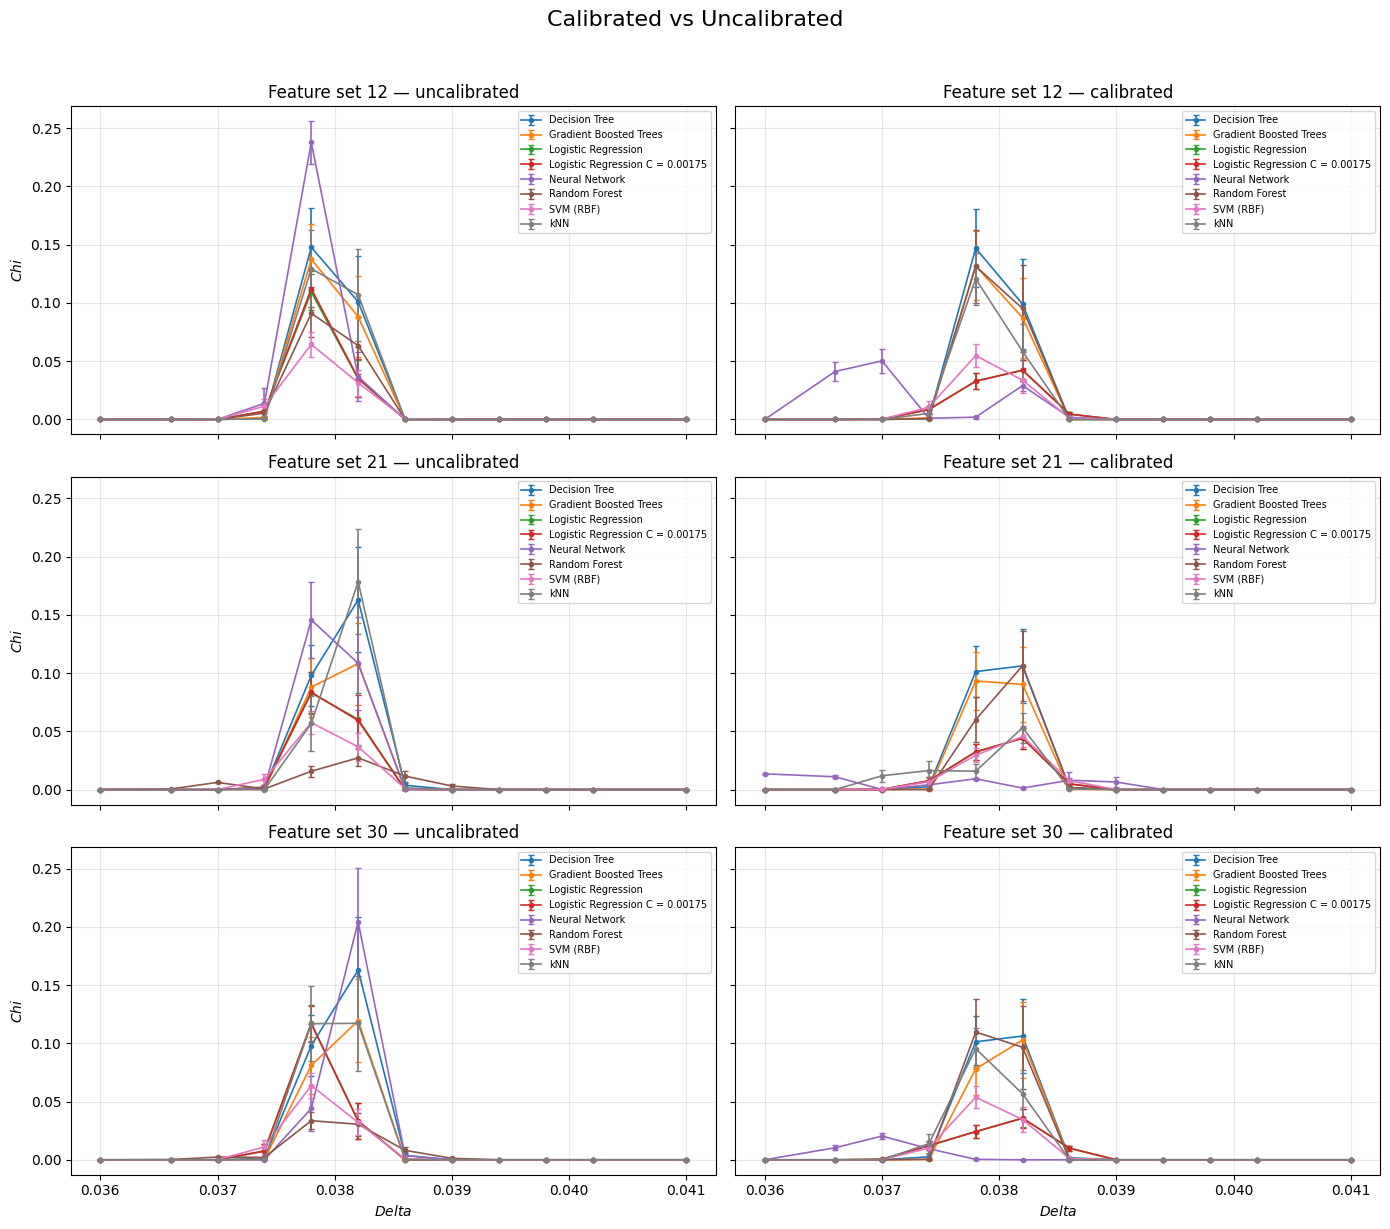

In [5]:
feature_sets = sorted(chi_df["feature_set"].unique())
calibrations = ["uncalibrated", "calibrated"]

fig, axes = plt.subplots(
    len(feature_sets),
    len(calibrations),
    figsize=(14, 4 * len(feature_sets)),
    sharex=True,
    sharey=True
)

# przypadek gdy jest tylko jeden feature_set
if len(feature_sets) == 1:
    axes = np.array([axes])

for i, fs in enumerate(feature_sets):

    for j, calib in enumerate(calibrations):

        ax = axes[i, j]

        df_plot = chi_df[
            (chi_df["feature_set"] == fs)
            &
            (chi_df["calibration"] == calib)
        ]

        for model, group in df_plot.groupby("model"):

            group = group.sort_values("Delta")

            ax.errorbar(
                group["Delta"],
                group["chi"],
                yerr=group["chi_err"],
                fmt="-o",
                markersize=3,
                capsize=2,
                linewidth=1.2,
                label=model
            )

        ax.set_title(
            f"Feature set {fs} — {calib}"
        )

        ax.grid(alpha=0.3)

        if j == 0:
            ax.set_ylabel(r"$Chi$")

        if i == len(feature_sets) - 1:
            ax.set_xlabel(r"$Delta$")

        ax.legend(
            fontsize=7,
            loc="best"
        )

plt.suptitle(
    "Calibrated vs Uncalibrated",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [6]:
table = (
    summary_df[
        [
            "model",
            "n_features",
            "calibration",
            "Delta_crit",
            "Delta_crit_err",
            "Delta_close",
            "runtime_total",
        ]
    ]
    .sort_values(
        ["model", "n_features", "calibration"]
    )
)

print(table.to_string(index=False))

                          model  n_features  calibration  Delta_crit  Delta_crit_err  Delta_close  runtime_total
                  Decision Tree          12   calibrated    0.037981        0.000028       0.0378         18.711
                  Decision Tree          12 uncalibrated    0.037982        0.000028       0.0378         14.776
                  Decision Tree          21   calibrated    0.037995        0.000030       0.0378         18.580
                  Decision Tree          21 uncalibrated    0.038025        0.000032       0.0382         15.781
                  Decision Tree          30   calibrated    0.037995        0.000030       0.0378         17.842
                  Decision Tree          30 uncalibrated    0.038025        0.000032       0.0382         15.894
         Gradient Boosted Trees          12   calibrated    0.037972        0.000028       0.0378         30.086
         Gradient Boosted Trees          12 uncalibrated    0.037969        0.000028       0.037

In [15]:
table = (
    summary_df[
        [
            "model",
            "n_features",
            "calibration",
            "K0_crit",
            "K0_crit_err",
            "runtime_total",
        ]
    ]
    .sort_values(
        ["model", "n_features", "calibration"]
    )
)

table["K0_crit"] = table["K0_crit"].round(4)
table["K0_crit_err"] = table["K0_crit_err"].round(4)
table["runtime_total"] = table["runtime_total"].round(2)

print(table.to_string(index=False))

                          model  n_features  calibration  K0_crit  K0_crit_err  runtime_total
                  Decision Tree          12   calibrated   4.7771       0.0006           4.98
                  Decision Tree          12 uncalibrated   4.7793       0.0006           4.19
                  Decision Tree          21   calibrated   4.7828       0.0007           5.71
                  Decision Tree          21 uncalibrated   4.7807       0.0008           4.68
                  Decision Tree          30   calibrated   4.7828       0.0007           6.16
                  Decision Tree          30 uncalibrated   4.7807       0.0008           5.03
         Gradient Boosted Trees          12   calibrated   4.7771       0.0006          12.89
         Gradient Boosted Trees          12 uncalibrated   4.7793       0.0006           8.07
         Gradient Boosted Trees          21   calibrated   4.7799       0.0006          17.57
         Gradient Boosted Trees          21 uncalibrated   4

In [6]:
print(
    summary_df[
        [
            "model",
            "calibration",
            "K0_crit",
            "K0_crit_err",
        ]
    ].to_latex(
        index=False,
        float_format="%.5f"
    )
)

\begin{tabular}{llrr}
\toprule
model & calibration & K0_crit & K0_crit_err \\
\midrule
Logistic Regression & calibrated & 4.77689 & 0.00078 \\
Logistic Regression & uncalibrated & 4.77551 & 0.00081 \\
Logistic Regression & calibrated & 4.77864 & 0.00080 \\
Logistic Regression & uncalibrated & 4.77579 & 0.00079 \\
Logistic Regression & calibrated & 4.77969 & 0.00087 \\
Logistic Regression & uncalibrated & 4.77882 & 0.00095 \\
\bottomrule
\end{tabular}



In [16]:
table = summary_df.copy()

table["K0"] = (
    table["K0_crit"].round(4).astype(str)
    + " ± "
    + table["K0_crit_err"].round(4).astype(str)
)

table = table[
    [
        "model",
        "n_features",
        "calibration",
        "K0",
        "K0_close",
        "runtime_total",
    ]
]

table = table.sort_values(
    ["model", "n_features", "calibration"]
)

print(table.to_string(index=False))

                          model  n_features  calibration              K0  K0_close  runtime_total
                  Decision Tree          12   calibrated 4.7771 ± 0.0006      4.78          4.978
                  Decision Tree          12 uncalibrated 4.7793 ± 0.0006      4.78          4.190
                  Decision Tree          21   calibrated 4.7828 ± 0.0007      4.78          5.712
                  Decision Tree          21 uncalibrated 4.7807 ± 0.0008      4.78          4.677
                  Decision Tree          30   calibrated 4.7828 ± 0.0007      4.78          6.164
                  Decision Tree          30 uncalibrated 4.7807 ± 0.0008      4.78          5.031
         Gradient Boosted Trees          12   calibrated 4.7771 ± 0.0006      4.78         12.890
         Gradient Boosted Trees          12 uncalibrated 4.7793 ± 0.0006      4.78          8.069
         Gradient Boosted Trees          21   calibrated 4.7799 ± 0.0006      4.78         17.571
         Gradient Bo

In [21]:
summary_table = (
    summary_df
    .groupby(
        ["n_features", "calibration"]
    )
    .agg(
        K0_crit_mean=("K0_crit", "mean"),
        K0_crit_std=("K0_crit", "std"),
        Err_mean=("K0_crit_err", "mean"),
        Runtime_mean=("runtime_total", "mean"),
        N_models=("model", "nunique")
    )
    .reset_index()
)

print(summary_table.round(4).to_string(index=False))

 n_features  calibration  K0_crit_mean  K0_crit_std  Err_mean  Runtime_mean  N_models
         12   calibrated        4.7764       0.0082    0.0007       15.4058         8
         12 uncalibrated        4.7725       0.0077    0.0007        8.7936         8
         21   calibrated        4.7775       0.0033    0.0007       37.9078         8
         21 uncalibrated        4.7771       0.0037    0.0007       22.0869         8
         30   calibrated        4.7772       0.0069    0.0007       34.3776         8
         30 uncalibrated        4.7751       0.0053    0.0007       20.6768         8


In [23]:
table = summary_df.copy()

table = table[
    (table["n_features"] == 30)
    &
    (table["calibration"] == "uncalibrated")
    ]

table = table[
    [
        "model",
        "K0_close",
        "runtime_total",
    ]
]

table = table.sort_values(
    ["model"]
)

print(table.to_string(index=False))

                          model  K0_close  runtime_total
                  Decision Tree      4.78          5.031
         Gradient Boosted Trees      4.78         13.629
            Logistic Regression      4.78          5.195
Logistic Regression C = 0.00175      4.77          6.104
                 Neural Network      4.78          6.725
                  Random Forest      4.78          7.357
                      SVM (RBF)      4.77         19.295
                            kNN      4.77        102.078
